In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import SelectFromModel
from keras import layers, models
import tensorflow as tf

# Mise en forme des données

In [33]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [34]:
print(f"Dimensions des données d'entrainement: {train.shape}")
print(f"Dimensions des données d'évaluation: {test.shape}")

Dimensions des données d'entrainement: (10000, 48)
Dimensions des données d'évaluation: (63544, 47)


In [35]:
train.head()

,Num_Acc,an,int,agg,dep,atm_0,atm_1,lum_0,lum_1,lum_2,...,grave,catu_1,catu_2,conducteur_confirmé_1,conducteur_confirmé_2,conducteur_confirmé_3,catv,obsm,choc,Nb_Vehicules
0,202000019452,20,1,0,29,1,0,1,0,0,...,1,0,0,1,0,0,5,2,1,2
1,202200004813,22,1,1,75,1,0,1,0,0,...,0,0,1,0,1,0,4,3,1,1
2,201000008868,10,1,0,30,1,0,1,0,0,...,1,0,0,0,1,0,4,2,3,2
3,201100062341,11,0,1,750,0,1,1,0,0,...,0,0,0,0,1,0,5,2,3,2
4,201100011477,11,0,0,130,1,0,1,0,0,...,1,0,0,0,0,1,5,0,1,1


In [36]:
test.head()

,Num_Acc,an,int,agg,dep,atm_0,atm_1,lum_0,lum_1,lum_2,...,utilisation,catu_1,catu_2,conducteur_confirmé_1,conducteur_confirmé_2,conducteur_confirmé_3,catv,obsm,choc,Nb_Vehicules
0,201200049538,12,0,0,930,1,0,1,0,0,...,1,0,0,0,1,0,4,2,2,3
1,201200004221,12,0,0,460,1,0,0,1,0,...,1,0,0,0,1,0,5,0,1,1
2,201200002457,12,0,0,850,1,0,0,0,1,...,1,0,0,0,1,0,5,2,1,2
3,201200009834,12,0,0,450,1,0,0,0,1,...,2,0,0,0,1,0,4,1,4,1
4,201200025602,12,2,1,330,1,0,0,1,0,...,0,0,0,0,1,0,5,2,3,2


In [37]:
y = train.loc[:, "grave"]
X = train.loc[:, ~train.columns.isin(["Num_Acc", "grave"])]

test2 = test.iloc[:, 1:]

In [38]:
print(f"Dimensions des données d'entrainement: {X.shape}, {y.shape}")
print(f"Dimensions des données d'évaluation: {test2.shape}")

Dimensions des données d'entrainement: (10000, 46), (10000,)
Dimensions des données d'évaluation: (63544, 46)


In [39]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25)

In [40]:
print(f"Dimensions des données d'entrainement: {X_train.shape}, {y_train.shape}")
print(f"Dimensions des données de test: {X_val.shape}, {y_val.shape}")

Dimensions des données d'entrainement: (7500, 46), (7500,)
Dimensions des données de test: (2500, 46), (2500,)


# Logistic regression

In [41]:
model = LogisticRegression(max_iter=10000)
clf = model.fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [42]:
accuracy_score(y_val, y_pred)

0.6908

In [43]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.6936170212765957
F1 score: 0.5585379782981154
recall: 0.46749521988527726


In [44]:
confusion_matrix(y_val, y_pred)

array([[1238,  216],
       [ 557,  489]], dtype=int64)

In [45]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.7249323419800591

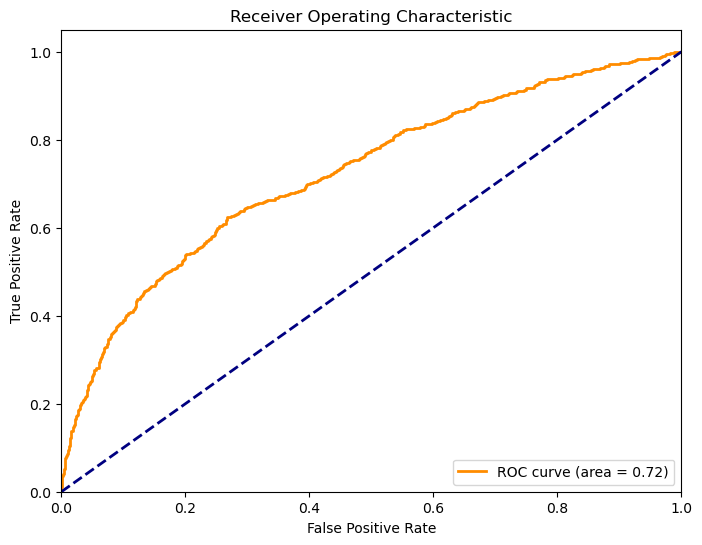

In [46]:
fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Decision Classifier

In [16]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [17]:
print(clf.get_depth())
print(clf.tree_.node_count)

32
3843


In [18]:
accuracy_score(y_val, y_pred)

0.632

In [19]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.6180569315104683

In [20]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.555
F1 score: 0.5467980295566502
recall: 0.5388349514563107


In [21]:
ccp_alphas = clf.cost_complexity_pruning_path(X_train, y_train)["ccp_alphas"]
print(len(ccp_alphas))

858


In [22]:
clfs = []
accuracy = []
precision = []
recall = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf = clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    clfs.append(clf)
    accuracy.append(accuracy_score(y_val, y_pred))


In [23]:
print(np.argmax(accuracy))

842


In [24]:
print(accuracy[np.argmax(accuracy)])
clfs[np.argmax(accuracy)]

0.6988


DecisionTreeClassifier(ccp_alpha=0.0011524811395771106, random_state=0)

In [25]:
clf = DecisionTreeClassifier(ccp_alpha=ccp_alphas[np.argmax(accuracy)], random_state=0)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
accuracy_score(y_val, y_pred)

0.6988

In [26]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.714064914992272
F1 score: 0.5509838998211091
recall: 0.44854368932038835


In [27]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.7122128657288157

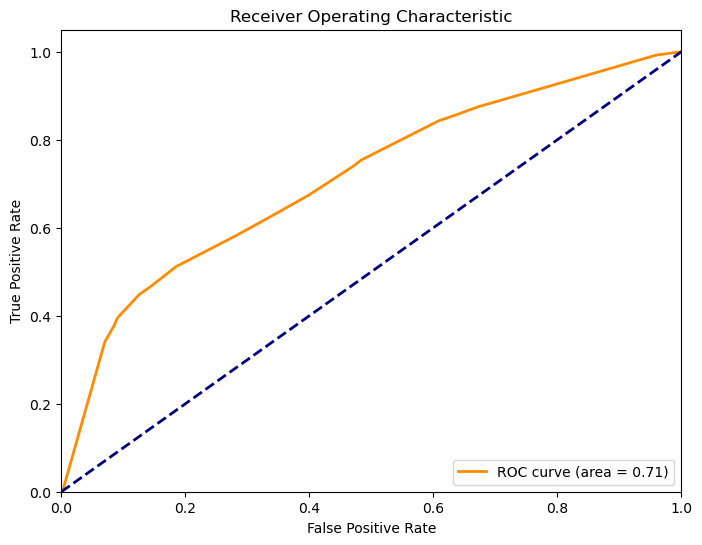

In [28]:
y_score = clf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Random forest

In [29]:
params = {
    "n_estimators": [100, 150, 200],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", 0.4, 0.5]
}

clf = RandomForestClassifier()
grid_search = GridSearchCV(clf, params, cv=5)
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'criterion': 'entropy', 'max_features': 0.5, 'n_estimators': 150}

In [30]:
params_forest = grid_search.best_params_

In [31]:
clf = RandomForestClassifier(**params_forest)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
accuracy_score(y_val, y_pred)

0.716

In [32]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.6904761904761905
F1 score: 0.6203208556149733
recall: 0.5631067961165048


In [33]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.7651261475463972

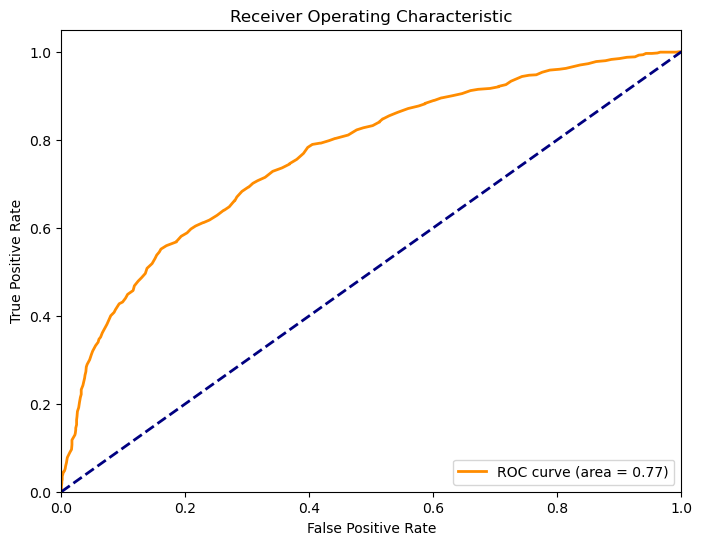

In [34]:
y_score = clf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [35]:
clf = RandomForestClassifier(**params_forest)

clf = clf.fit(X_train, y_train)

feature_importances = clf.feature_importances_

sorted_indices = np.argsort(feature_importances)[::-1]
sorted_feature_names = X_train.columns[sorted_indices]
sorted_feature_importances = feature_importances[sorted_indices]

for name, importance in zip(sorted_feature_names, sorted_feature_importances):
    print(f"Feature {name}: Importance = {importance}")

Feature 1: Importance = 0.08957860097729137
Feature 2: Importance = 0.032358362284579126
Feature 3: Importance = 0.04441052411798301
Feature 4: Importance = 0.17981871216970843
Feature 5: Importance = 0.007779726187390883
Feature 6: Importance = 0.00720033777580479
Feature 7: Importance = 0.01345878900796744
Feature 8: Importance = 0.012376181256860162
Feature 9: Importance = 0.009303289380993594
Feature 10: Importance = 0.011053475121878062
Feature 11: Importance = 0.004293845129744957
Feature 12: Importance = 0.008907747999822947
Feature 13: Importance = 0.01559470276585589
Feature 14: Importance = 0.017598353868721293
Feature 15: Importance = 0.018148764726667203
Feature 16: Importance = 0.010944306515890047
Feature 17: Importance = 0.017527294731853146
Feature 18: Importance = 0.01951310065695843
Feature 19: Importance = 0.020583633271188027
Feature 20: Importance = 0.02404062027989389
Feature 21: Importance = 0.039681493882726494
Feature 22: Importance = 0.048000398716668606
Featu

In [36]:
# Sélectionner les fonctionnalités avec une importance supérieure à un seuil donné
sfm = SelectFromModel(clf, threshold=0.015)
sfm.fit(X_train, y_train)

# Transformer les données pour inclure uniquement les fonctionnalités sélectionnées
X_train2 = sfm.transform(X_train)
X_val2 = sfm.transform(X_val)

# Afficher les dimensions des données après sélection des fonctionnalités
print("Nombre de fonctionnalités avant la sélection :", X_train.shape[1])
print("Nombre de fonctionnalités après la sélection :", X_train2.shape[1])
print("Nombre de fonctionnalités de validation avant la sélection :", X_val.shape[1])
print("Nombre de fonctionnalités de validation après la sélection :", X_val2.shape[1])

Nombre de fonctionnalités avant la sélection : 44
Nombre de fonctionnalités après la sélection : 24
Nombre de fonctionnalités de validation avant la sélection : 44
Nombre de fonctionnalités de validation après la sélection : 24


In [37]:
clf = RandomForestClassifier(**params_forest)
clf = clf.fit(X_train2, y_train)
y_pred = clf.predict(X_val2)
accuracy_score(y_val, y_pred)

0.71

In [38]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.6792009400705052
F1 score: 0.6145667198298778
recall: 0.5611650485436893


In [39]:
y_score = clf.predict_proba(X_val2)[:, 1]
roc_auc_score(y_val, y_score)

0.7588811835413777

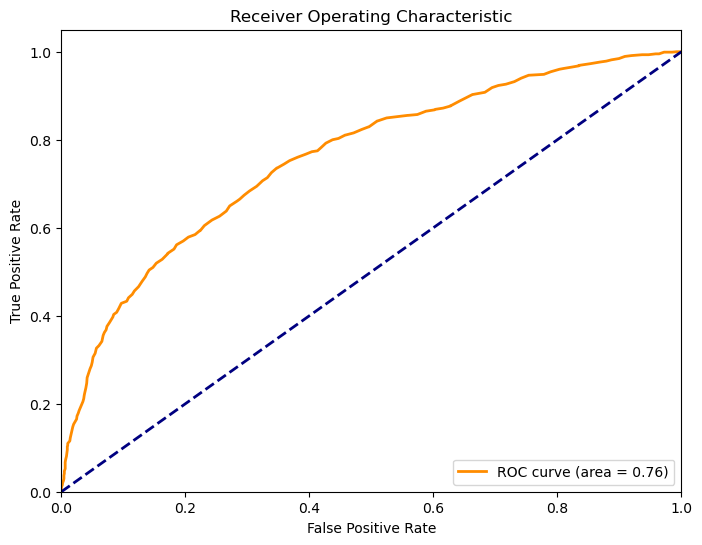

In [40]:
y_score = clf.predict_proba(X_val2)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Boosting

In [15]:
parametres = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.01, 0.1],
    'max_depth': [3, 5, 7]
}

gb_clf = GradientBoostingClassifier()

grid_search = GridSearchCV(estimator=gb_clf, param_grid=parametres, cv=5)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.01, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 150, 200]})

In [16]:
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

In [17]:
params_boosting = grid_search.best_params_

In [47]:
clf = GradientBoostingClassifier(**params_boosting)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
accuracy_score(y_val, y_pred)

0.7212

In [48]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.7146371463714637
F1 score: 0.6250672404518558
recall: 0.5554493307839388


In [49]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.7866089721504073

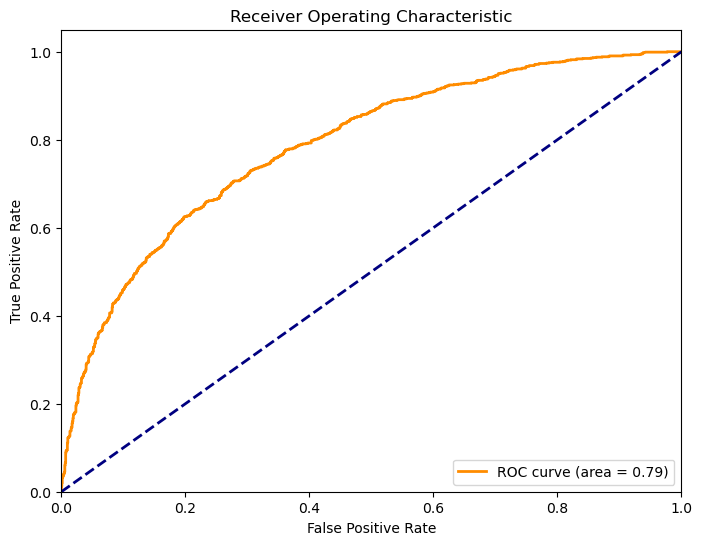

In [50]:
y_score = clf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [51]:
clf = GradientBoostingClassifier(**params_boosting)

clf = clf.fit(X_train, y_train)

feature_importances = clf.feature_importances_

sorted_indices = np.argsort(feature_importances)[::-1]
sorted_feature_names = X_train.columns[sorted_indices]
sorted_feature_importances = feature_importances[sorted_indices]

# Afficher les noms de colonnes et les importances de caractéristiques triées
for name, importance in zip(sorted_feature_names, sorted_feature_importances):
    print(f"Feature {name}: Importance = {importance}")

Feature dep: Importance = 0.2235962336237401
Feature agg: Importance = 0.16281195410697621
Feature catr_1: Importance = 0.09574916237932707
Feature choc: Importance = 0.04448743506338349
Feature an: Importance = 0.03949596391912018
Feature equipement: Importance = 0.038742609643940086
Feature circ: Importance = 0.036728103561094926
Feature nbv_3: Importance = 0.03286521408318944
Feature Nb_Vehicules: Importance = 0.029288046063651884
Feature int: Importance = 0.026054649998895642
Feature utilisation: Importance = 0.025135560401316058
Feature obsm: Importance = 0.023224235094949395
Feature catv: Importance = 0.019956595509429017
Feature prof_0: Importance = 0.015885770712396687
Feature surf: Importance = 0.011760276395856141
Feature lum_2: Importance = 0.01124191339760421
Feature env1: Importance = 0.009865784326633808
Feature catu_2: Importance = 0.009803491265073268
Feature conducteur_confirmé_3: Importance = 0.009743743190491509
Feature catu_1: Importance = 0.009656354116027634
Featu

In [28]:
# Sélectionner les fonctionnalités avec une importance supérieure à un seuil donné
sfm = SelectFromModel(clf, threshold=0.003)
sfm.fit(X_train, y_train)

# Transformer les données pour inclure uniquement les fonctionnalités sélectionnées
X_train2 = sfm.transform(X_train)
X_val2 = sfm.transform(X_val)

# Afficher les dimensions des données après sélection des fonctionnalités
print("Nombre de fonctionnalités avant la sélection :", X_train.shape[1])
print("Nombre de fonctionnalités après la sélection :", X_train2.shape[1])
print("Nombre de fonctionnalités de validation avant la sélection :", X_val.shape[1])
print("Nombre de fonctionnalités de validation après la sélection :", X_val2.shape[1])

Nombre de fonctionnalités avant la sélection : 44
Nombre de fonctionnalités après la sélection : 37
Nombre de fonctionnalités de validation avant la sélection : 44
Nombre de fonctionnalités de validation après la sélection : 37


In [29]:
clf = GradientBoostingClassifier(**params_boosting)
clf = clf.fit(X_train2, y_train)
y_pred = clf.predict(X_val2)
accuracy_score(y_val, y_pred)

0.7252

In [30]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.6942675159235668
F1 score: 0.6133933595948228
recall: 0.5493951612903226


In [31]:
y_score = clf.predict_proba(X_val2)[:, 1]
roc_auc_score(y_val, y_score)

0.7838139465859503

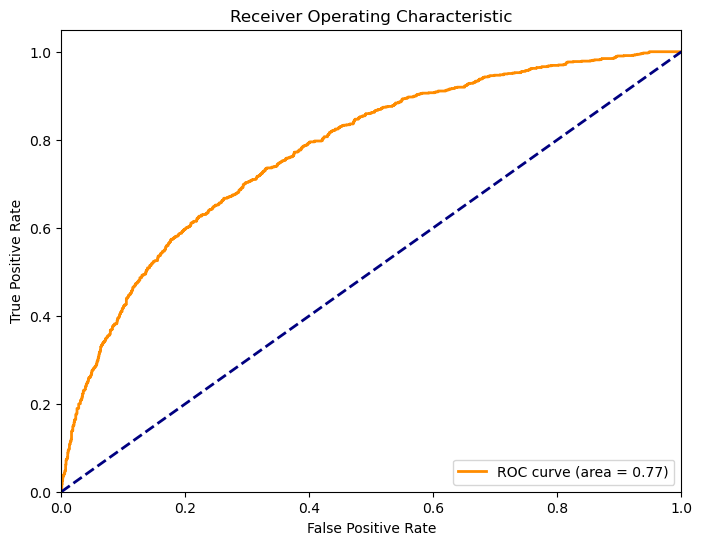

In [53]:
y_score = clf.predict_proba(X_val2)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Ridge

In [54]:
clf = RidgeClassifier(alpha=15)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
print(accuracy_score(y_val, y_pred))

y_score = clf.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.6944


0.7358562842612774

In [55]:
ridge_alphas = (1, 5, 10, 15, 30, 50)

# cross-validation strategy
cv = KFold(n_splits=5)

# models
ridge_cv = RidgeClassifierCV(alphas=ridge_alphas, cv=cv)

# train
ridge_cv.fit(X_train, y_train)

y_pred = ridge_cv.predict(X_val)
print(accuracy_score(y_val, y_pred))
print(ridge_cv.alpha_)

y_score = ridge_cv.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.6936
1


0.735847698302622

# SVC

In [57]:
model = LinearSVC(C=0.1, dual="auto")

model.fit(X_train, y_train)

predictions = model.predict(X_val)

print(accuracy_score(y_val, predictions))
y_score = model.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.6932


0.7353589591176277

# Stacking

In [58]:
# base models
ensemble_models = [
    ('Logistic regression', LogisticRegression(max_iter=10000)),
    ("Linear SVC", LinearSVC(C=0.1, dual="auto")),
    ("Ridge", RidgeClassifier(alpha=ridge_cv.alpha_)),
    ('Tree Classifier', DecisionTreeClassifier(ccp_alpha=ccp_alphas[np.argmax(accuracy)], random_state=0)),
    ('Random forest', RandomForestClassifier(**params_forest)),
    ('Boosting', GradientBoostingClassifier(**params_boosting))
]


In [59]:
stacking = StackingClassifier(ensemble_models, final_estimator=RandomForestClassifier())

stacking.fit(X_train, y_train)

y_pred = stacking.predict(X_val)
    
acc = accuracy_score(y_val, y_pred)
    
y_score = stacking.predict_proba(X_val)[:, 1]
        
roc = roc_auc_score(y_val, y_score)

print('K-fold stacking: {:.4f}, {:.4f}'.format(acc, roc))

K-fold stacking: 0.7004, 0.7565


In [60]:
stacking2 = StackingClassifier(ensemble_models, final_estimator=GradientBoostingClassifier())

stacking2.fit(X_train2, y_train)

y_pred = stacking2.predict(X_val2)
    
acc = accuracy_score(y_val, y_pred)
    
y_score = stacking2.predict_proba(X_val2)[:, 1]
        
roc = roc_auc_score(y_val, y_score)

print('K-fold stacking: {:.4f}, {:.4f}'.format(acc, roc))

K-fold stacking: 0.7096, 0.7693


# Neural network

In [61]:
neural_model1 = models.Sequential()
neural_model1.add(layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
neural_model1.add(layers.Dense(128, activation='relu'))
neural_model1.add(layers.Dropout(0.1))
neural_model1.add(layers.Dense(1, activation='sigmoid'))

neural_model1.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy', tf.keras.metrics.AUC()])

history = neural_model1.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

C:\Users\adrie\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5755 - auc: 0.5122 - loss: 0.3992 - val_accuracy: 0.5924 - val_auc: 0.5013 - val_loss: 0.3825
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6013 - auc: 0.5218 - loss: 0.3683 - val_accuracy: 0.5964 - val_auc: 0.5110 - val_loss: 0.3839
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5936 - auc: 0.5090 - loss: 0.3717 - val_accuracy: 0.5868 - val_auc: 0.4884 - val_loss: 0.3697
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5601 - auc: 0.5076 - loss: 0.4045 - val_accuracy: 0.6028 - val_auc: 0.4911 - val_loss: 0.3667
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5902 - auc: 0.5225 - loss: 0.3661 - val_accuracy: 0.6068 - val_auc: 0.4897 - val_loss: 0.3633
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5783 - auc: 0.5187 - loss: 0.3678 - val_accuracy: 0.5992 - val_auc: 0.4910 - val_loss: 0.3655
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [62]:
predictions = neural_model1.predict(test2)

1986/1986 ━━━━━━━━━━━━━━━━━━━━ 2s 757us/step


In [63]:
predictions[:, 0]

array([0.13435541, 0.7677763 , 0.72585595, ..., 0.7385453 , 0.3682464 ,
       0.03542972], dtype=float32)

# Predictions

In [14]:
probas = clf.predict_proba(test2)

probas_grave = probas[:, 1]

In [90]:
probas = stacking2.predict_proba(sfm.transform(test2))

probas_grave = probas[:, 1]

In [15]:
rendu = pd.DataFrame({"Num_Acc": test.iloc[:, 0], "GRAVE": probas_grave})

In [16]:
rendu.head()

,Num_Acc,GRAVE
0,201200049538,0.151348
1,201200004221,0.869118
2,201200002457,0.951583
3,201200009834,0.909958
4,201200025602,0.256282


In [17]:
rendu.shape

(63544, 2)

In [18]:
len(rendu["Num_Acc"].unique())

63544

In [19]:
rendu.to_csv("rendu.csv", index=False)